In [1]:
from stable_baselines3 import A2C, DDPG, PPO, SAC, TD3
from src.eval import visualize_simulation
from src.callback import env_callback

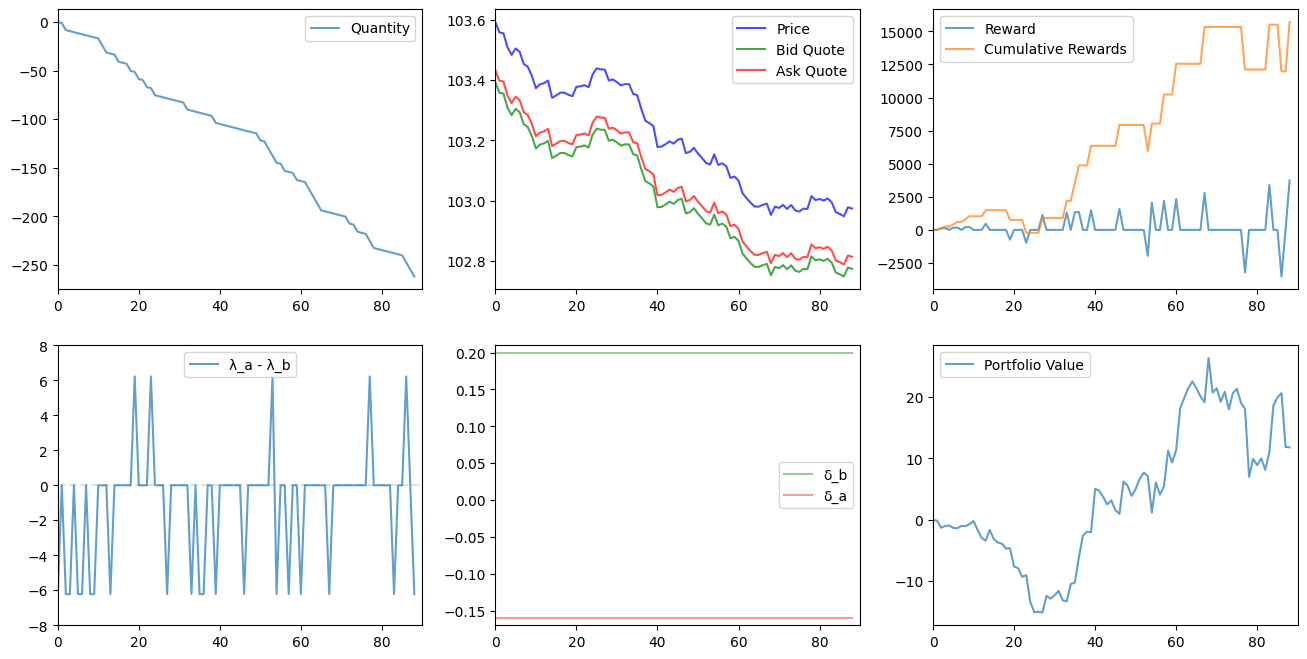

In [2]:
# model = PPO.load("models/PPO_2000000_steps")
model = A2C.load("models/A2C_8000_steps")
# model = DDPG.load("models/DDPG_8000_steps")

visualize_simulation(env_callback(), model, sleep=0.01)

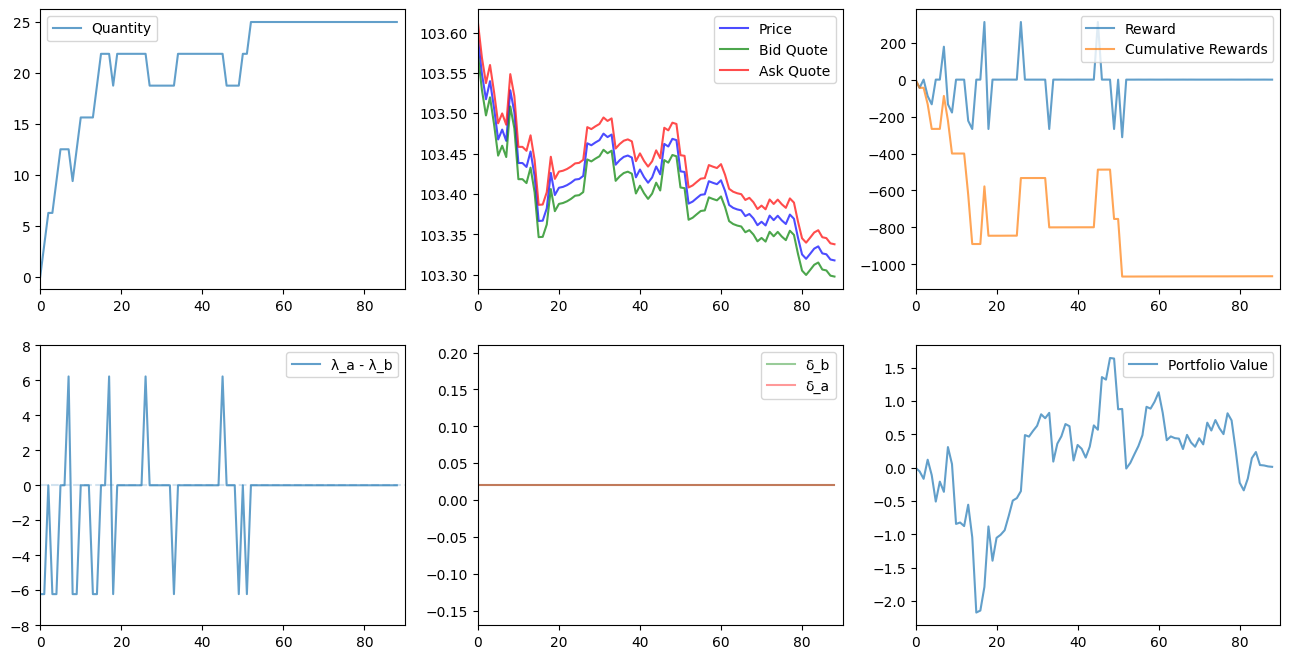

In [3]:
class FixedModel:
    def predict(self, _, deterministic=True):
        return [0.02, 0.02], None


visualize_simulation(env_callback(), FixedModel(), sleep=0.01)

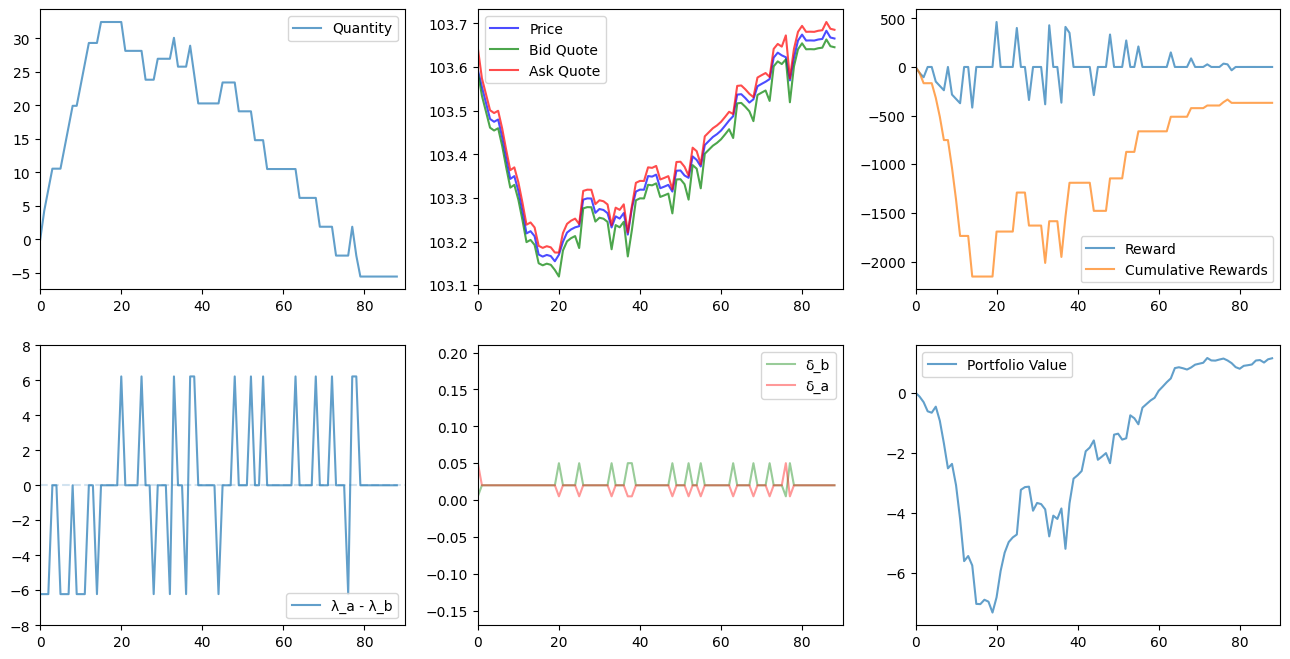

In [4]:
class Hedger:
    def predict(self, state, deterministic=True):
        price_delta = state[0] - state[1]
        n_shares = state[2]

        if price_delta < 0:  # going to go down
            if n_shares < 0:
                return [0.02, 0.02], None
            return [0.05, 0.005], None
        elif price_delta == 0:  # stationary
            return [0.02, 0.02], None
        else:  # going up
            if n_shares > 0:
                return [0.02, 0.02], None
            return [0.005, 0.05], None


visualize_simulation(env_callback(), Hedger(), sleep=0.01)